False
Channel types::	eeg: 29


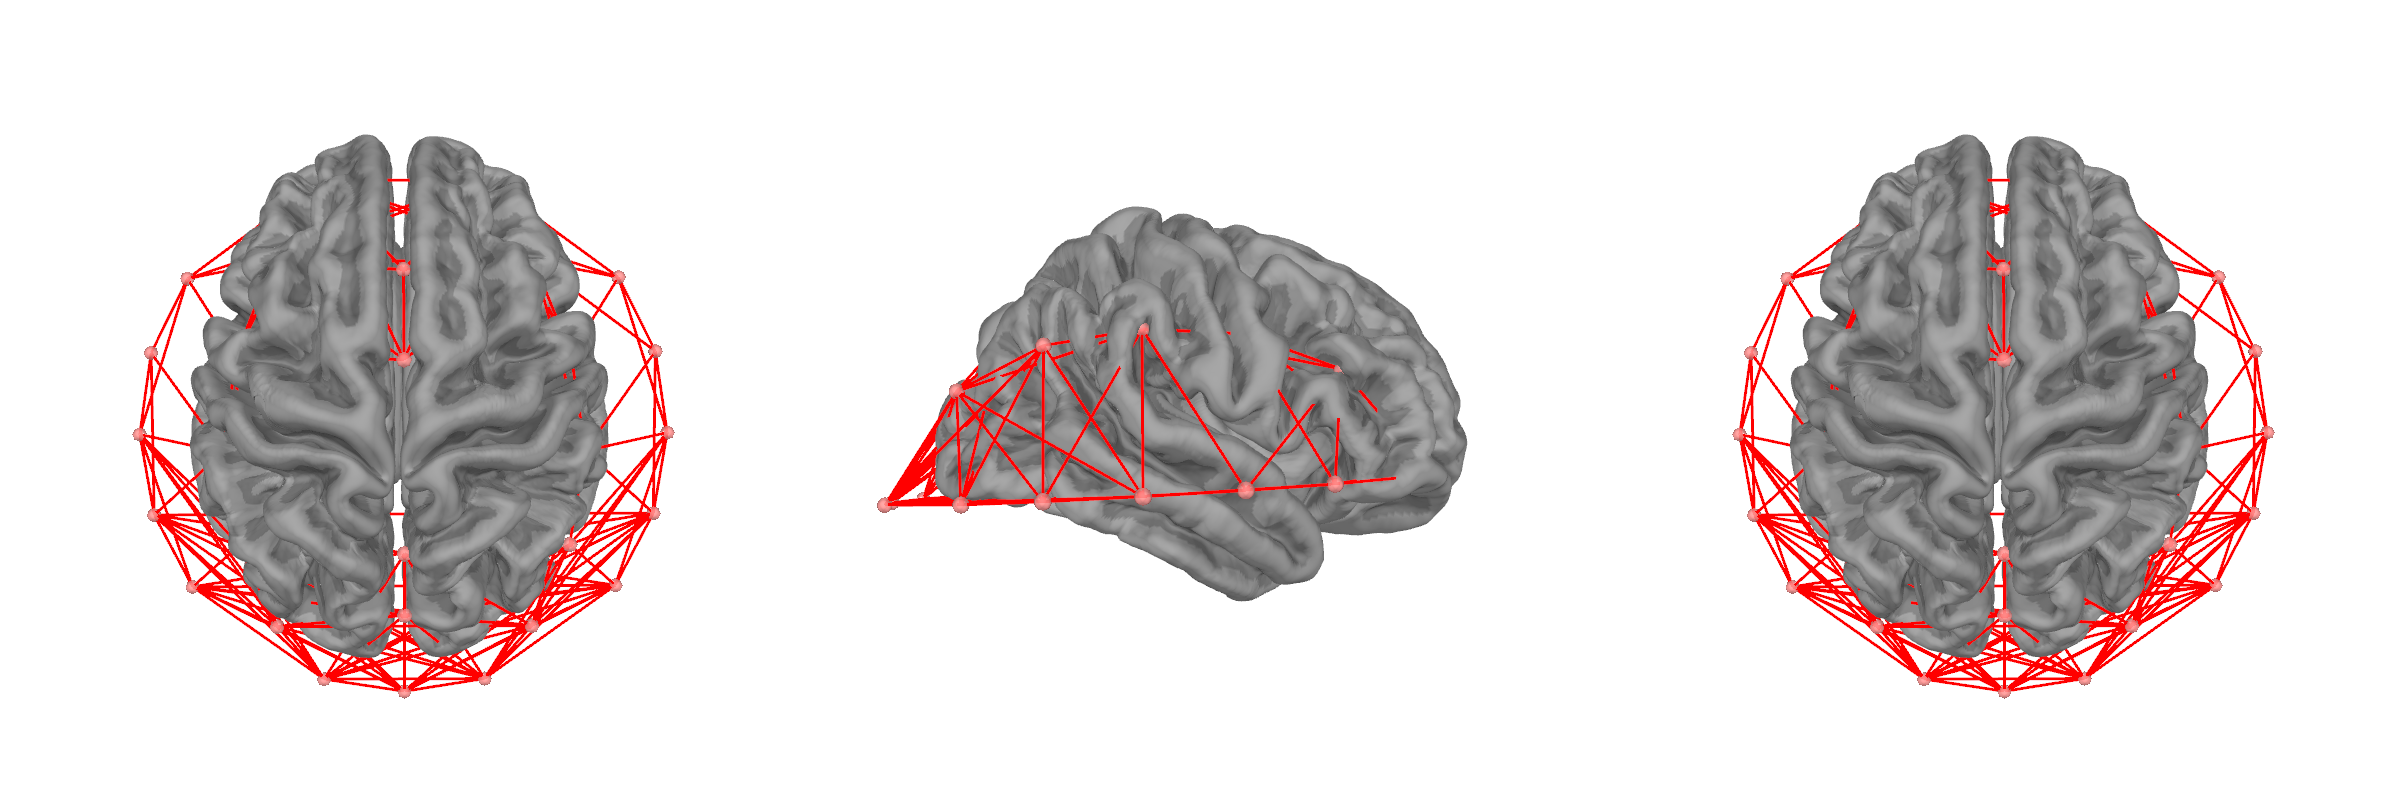

BD-II COH | delta
False
Channel types::	eeg: 29


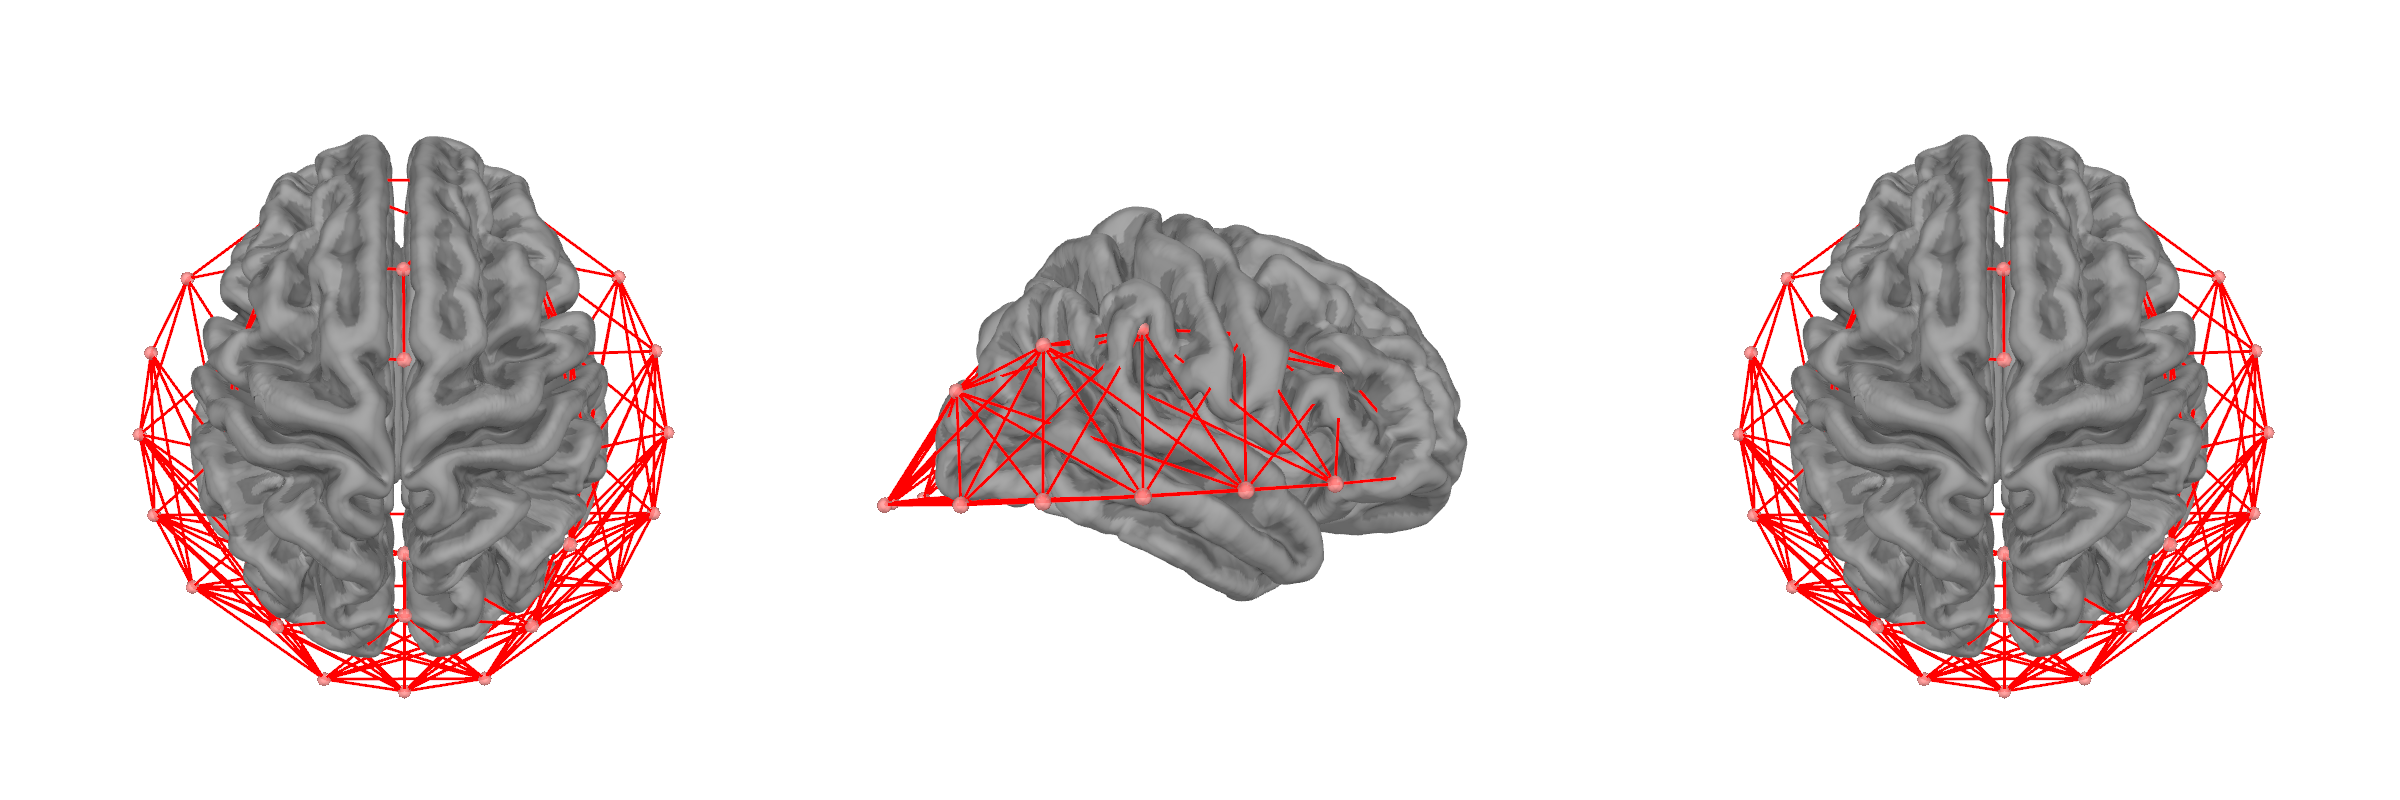

BD-II COH | theta
False
Channel types::	eeg: 29


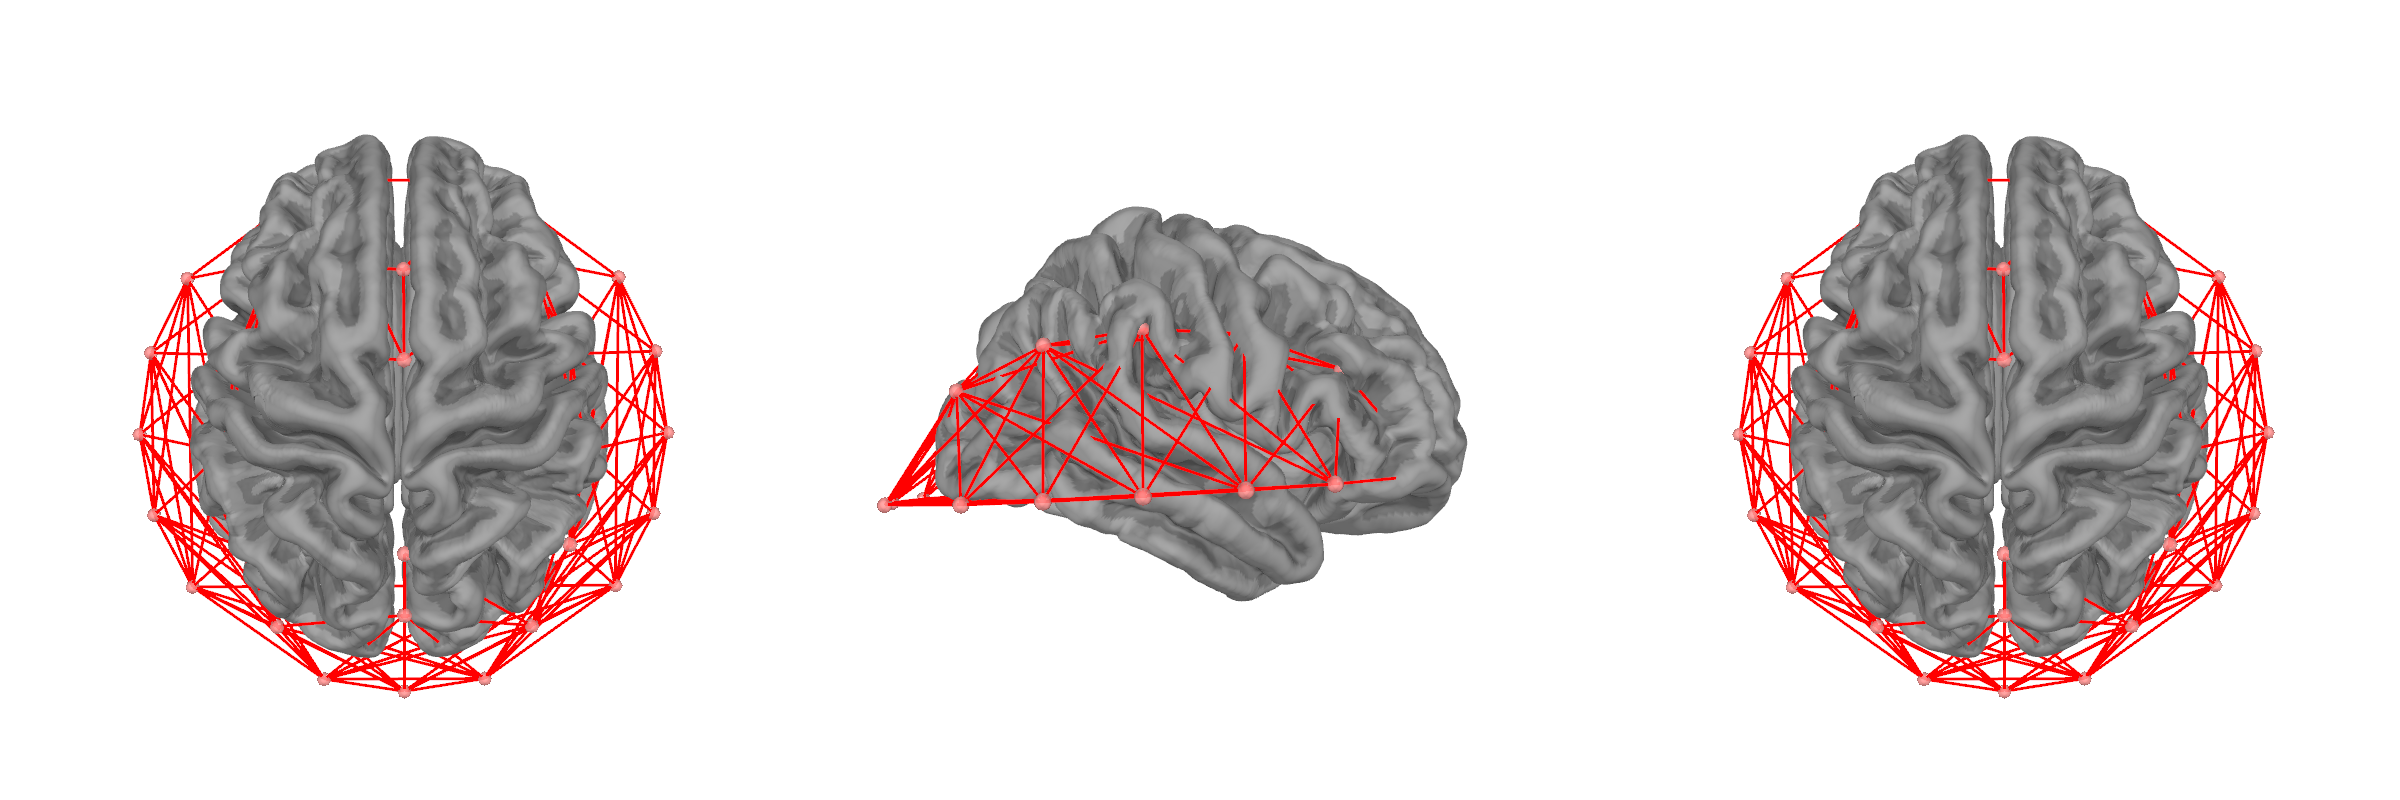

BD-II COH | alpha
False
Channel types::	eeg: 29


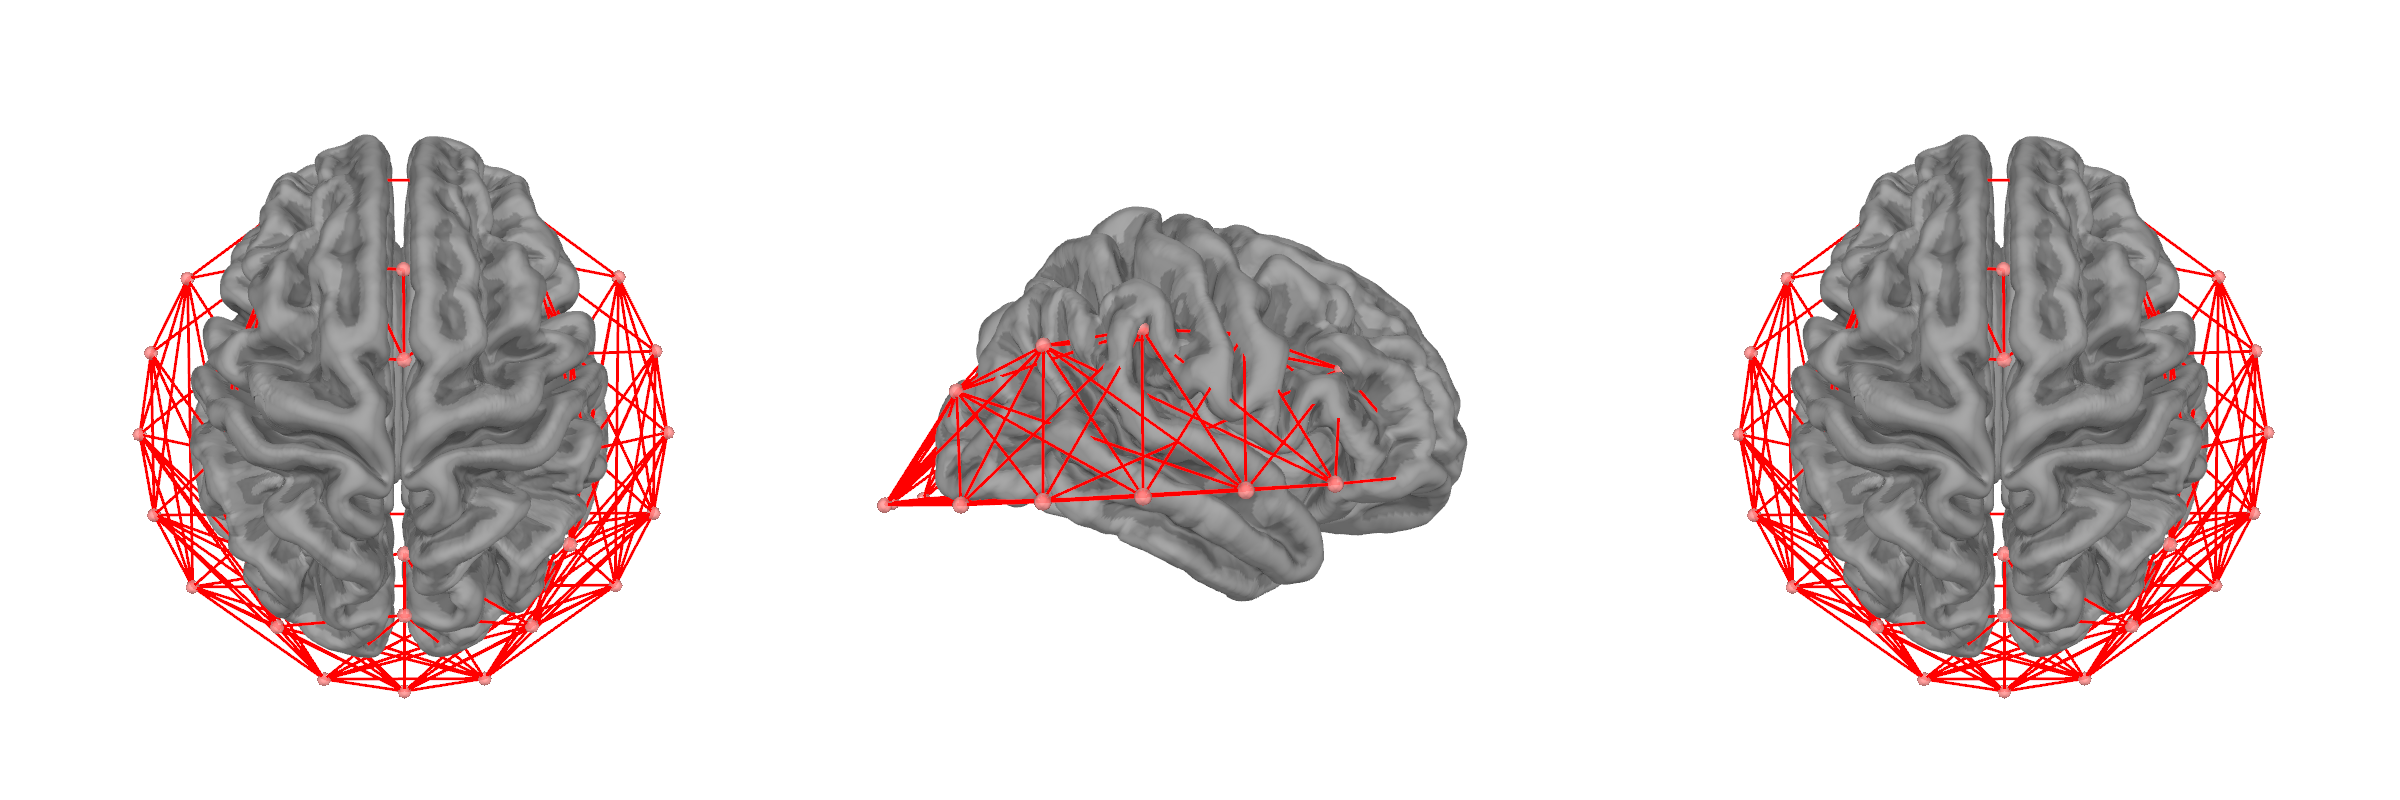

BD-II COH | betalow
False


KeyboardInterrupt: 

In [3]:
# ────────────────────────────────────────────────
# 0. 套件與後端設定
# ────────────────────────────────────────────────
import pickle, numpy as np, mne, os.path as op
from pathlib import Path
from mne.viz import set_3d_backend
from mne.datasets import fetch_fsaverage
from mne.transforms import Transform, apply_trans
from PIL import Image as PILImage
from IPython.display import display

set_3d_backend("notebook")          # Notebook 內嵌互動

# ────────────────────────────────────────────────
# 1. 讀取 pickle 與計算群體平均
# ────────────────────────────────────────────────
def load_pickle(p):
    with open(p, "rb") as f:
        return pickle.load(f)

root = "../data"                    # ← 依實際路徑調整
BD_coh = load_pickle(f"{root}/COH/BD_coh_data.pkl")
MDD_coh = load_pickle(f"{root}/COH/MDD_coh_data.pkl")
BD_pli = load_pickle(f"{root}/PLI/BD_pli_data.pkl")
MDD_pli = load_pickle(f"{root}/PLI/MDD_pli_data.pkl")
BD_ste = load_pickle(f"{root}/STE/BD_ste_data.pkl")
MDD_ste = load_pickle(f"{root}/STE/MDD_ste_data.pkl")

montage = mne.channels.read_custom_montage("../電極通道/BD_MDD_HC_29_test.loc")
ch_names, n_chan = montage.ch_names, len(montage.ch_names)
freqs = ["delta", "theta", "alpha", "betalow", "betahigh", "gamma"]

def vec2mat(vec):
    m = np.zeros((n_chan, n_chan))
    iu = np.triu_indices(n_chan, 1)
    m[iu] = vec
    m[(iu[1], iu[0])] = vec
    return m

def group_avg(d, sym=False):
    out = {}
    for f in freqs:
        mats = []
        for subj in d.values():
            mat = subj[f] if subj[f].ndim == 2 else vec2mat(subj[f])
            if sym:
                mat = (mat + mat.T) / 2
            mats.append(mat)
        out[f] = np.mean(mats, 0)
    return out

BD_avg = {"COH": group_avg(BD_coh),
          "PLI": group_avg(BD_pli),
          "STE": group_avg(BD_ste, sym=True)}
MDD_avg = {"COH": group_avg(MDD_coh),
           "PLI": group_avg(MDD_pli),
           "STE": group_avg(MDD_ste, sym=True)}

# ────────────────────────────────────────────────
# 2. 只取最強 n_top 條邊
# ────────────────────────────────────────────────
def strongest_mask(mat, n_top=120):
    iu = np.triu_indices_from(mat, 1)
    vals = mat[iu]
    if n_top >= len(vals):
        return np.ones_like(mat, bool)
    thr = np.partition(vals, -n_top)[-n_top]
    return mat >= thr

# ────────────────────────────────────────────────
# 3. 建立 fsaverage 大腦＆電極
# ────────────────────────────────────────────────
subjects_dir = Path(fetch_fsaverage(verbose=False)).parent
brain_opts = dict(
    subjects_dir=str(subjects_dir),
    background="white",
    cortex="low_contrast",
    show=False,
)

info = mne.create_info(ch_names, sfreq=1000., ch_types="eeg")
info.set_montage(montage)

# 讀取官方 head→mri 轉換矩陣
head2mri = mne.read_trans(
    op.join(str(subjects_dir), "fsaverage", "bem", "fsaverage-trans.fif")
)

_identity_trans = Transform("head", "meg", np.eye(4))  # 最舊版後備

def make_brain():
    brain = mne.viz.Brain("fsaverage", hemi="both", surf="pial", **brain_opts)

    # 放大電極球（依版本兼容）
    try:                                                  # MNE ≥ 1.6
        brain.add_sensors(info, trans=None, meg=False, eeg=True, sphere=3)
    except TypeError:                                     # MNE 1.4–1.5
        try:
            brain.add_sensors(info, trans="fsaverage",
                              meg=False, eeg=True, sensor_scales=5.0)
        except TypeError:                                 # 更舊版
            brain.add_sensors(info, trans=_identity_trans,
                              meg=False, eeg=True)
            brain._sensor_markers.glyph.scale = np.array([6, 6, 6])

    # 轉換座標：head(m) → mri(m) → mri(mm)
    xyz_head_m = np.array([ch["loc"][:3] for ch in info["chs"]])
    xyz_mri_m  = apply_trans(head2mri["trans"], xyz_head_m)
    xyz_mm     = xyz_mri_m * 1e3
    return brain, xyz_mm

# ────────────────────────────────────────────────
# 4. 畫網路並截三視角
# ────────────────────────────────────────────────
def plot_brain_network(mat, title, n_top=120, line_px=10):
    brain, xyz = make_brain()
    mask = strongest_mask(mat, n_top)

    for i, j in zip(*np.triu_indices(n_chan, 1)):
        if mask[i, j]:
            brain._renderer.plotter.add_lines(
                xyz[[i, j]], color="red", width=line_px)

    # 三視角 (azimuth, elevation, distance)
    views = [(-90, 0, 500), (0, 90, 500), (90, 0, 500)]
    shots = []
    for az, el, dist in views:
        brain.show_view(azimuth=az, elevation=el, distance=dist)
        shots.append(PILImage.fromarray(brain.screenshot(mode="rgb")))
    brain.close()

    # 合併三張圖
    w, h = zip(*(im.size for im in shots))
    canvas = PILImage.new("RGB", (sum(w), max(h)), "white")
    x = 0
    for im in shots:
        canvas.paste(im, (x, 0))
        x += im.size[0]
    display(canvas); print(title)

# ────────────────────────────────────────────────
# 5. 批次產圖
# ────────────────────────────────────────────────
for grp, data in [("BD-II", BD_avg), ("MDD", MDD_avg)]:
    for conn_kind in ["COH", "PLI", "STE"]:
        for band in freqs:
            plot_brain_network(
                data[conn_kind][band],
                f"{grp} {conn_kind} | {band}",
                n_top=120,   # 每圖保留 120 條最強邊
                line_px=3   # 粗紅線
            )
